# **LemonTree Module Analysis Pipeline**

**Purpose**: Generate gene regulatory networks from LemonTree tight clusters with coherence-based quality control and regulator score filtering.

## **Configuration Parameters**:

### **Filtering Thresholds**:
- `coherence_threshold = 0.6`: Minimum module coherence score to retain modules
- **Module prioritization**: All modules ordered by coherence scores (higher = better quality)

### **File Paths**:
- `expression_complete`: Complete expression data with gene symbols
- `clusterfile`: LemonTree tight clusters (module assignments)
- `allregfile_TF/metabolites`: All regulator scores from LemonTree
- `randomregfile_TF/metabolites`: Random background scores
- `DESeq_groups`: Sample condition annotations (UC vs nonIBD)

### **Analysis Variables**:
- `cluster2gene`: Dictionary mapping module IDs to gene lists
- `cluster2color`: Visual formatting for module networks
- `reg2score`: Regulator importance scores from LemonTree
- `randomdist`: Background score distribution for significance testing

## **Key Functions**:
- `Prioritize_modules_coherence()`: Orders modules by eigengene coherence scores
- Module filtering by quality control metrics
- Network generation with filtered regulator sets
- Statistical significance testing vs. random background

In [1]:
#####################################################################################################################################
#### Prepare input data for moduleviewer
#####################################################################################################################################
import os
import sys
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
import numpy as np

os.chdir('/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/results/LemonTree/noProteomics_percentile2_divide_by_sum/')

#data_folder = '/home/boris/Documents/PhD/gut_brain/IBD/Lloyd-Price2019/data/'
res_folder = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/results/LemonTree/noProteomics_percentile2_divide_by_sum/ModuleViewer_files/'
expression_location = './Preprocessing/LemonPreprocessed_expression.txt'
expression_complete = './Preprocessing/LemonPreprocessed_complete.txt'
DESeq_groups = './Preprocessing/DESeq_groups.txt'
clusterfile = './Lemon_out/tight_clusters.txt'
topregfile_TF = './Lemon_out/Lovering.topreg.txt'
allregfile_TF = './Lemon_out/Lovering.allreg.txt'
randomregfile_TF = './Lemon_out/Lovering.randomreg.txt'
topregfile_metabolites = './Lemon_out/Metabolites.topreg.txt'
allregfile_metabolites = './Lemon_out/Metabolites.allreg.txt'
randomregfile_metabolites = './Lemon_out/Metabolites.randomreg.txt'
allregfile_lipids = './Lemon_out/Lipids.allreg.txt'
randomregfile_lipids = './Lemon_out/Lipids.randomreg.txt'
topregfile_lipids = './Lemon_out/Lipids.topreg.txt'

allregfile_lovering_proteins = './Lemon_out/Lovering_proteins.allreg.txt'
randomregfile_lovering_proteins = './Lemon_out/Lovering_proteins.randomreg.txt'
topregfile_lovering_proteins = './Lemon_out/Lovering_proteins.topreg.txt'

percentile = 2
coherence_threshold = 0.5

In [2]:
metadata2 = pd.read_csv('/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/Additional_sample_annotations_suppl2.csv', sep='\t', index_col=0)
metadata2
# Get columns with mutation data, these have *_alter_status in the column name
mutation_cols = [col for col in metadata2.columns if '_alter_status' in col]
# In the mutation columns, replace NAs by 'No' and all other values by 'Yes'
metadata2[mutation_cols] = metadata2[mutation_cols].fillna('No')
# If not 'No', put 'Yes'
metadata2[mutation_cols] = metadata2[mutation_cols].applymap(lambda x: 'Yes' if x != 'No' else x)
metadata2


/tmp/ipykernel_9256/2870012647.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  metadata2[mutation_cols] = metadata2[mutation_cols].applymap(lambda x: 'Yes' if x != 'No' else x)


,sample_type,multiomic,nmf_consensus,nmf_cluster_membership,rna_wang_cancer_cell_2017,mRNA_stemness_index,dna_methyl,dna_methyl_consensus,dna_methyl_mnp,is_gcimp,...,PDGFRA_alter_status,PIK3CA_alter_status,BRAF_alter_status,RB1_alter_status,ATRX_alter_status,IDH1_alter_status,PIK3R1_alter_status,TERT_alter_status,chr7_amp,chr10_del
case,,,,,,,,,,,,,,,,,,,,,
C3L-00104,tumor,nmf1,nmf1,0.743,Proneural,0.678244,dm2,0.314081,"GBM, RTK II",1.0,...,No,No,No,Yes,No,No,No,Yes,1.0,1.0
C3L-00365,tumor,nmf3,nmf3,0.614,Classical,0.681122,dm4,0.891149,"GBM, RTK II",0.0,...,No,No,No,Yes,No,No,No,Yes,1.0,1.0
C3L-00674,tumor,nmf1,nmf1,0.507,Mesenchymal,0.744635,dm5,0.625634,"GBM, MES",0.0,...,No,No,No,No,No,No,No,Yes,1.0,1.0
C3L-00677,tumor,nmf1,nmf1,0.536,Proneural,0.900896,dm5,0.406474,"GBM, MES",0.0,...,No,No,No,Yes,Yes,No,No,No,1.0,1.0
C3L-01040,tumor,nmf1,nmf1,0.589,Classical,0.647288,dm5,0.623458,"GBM, MES",0.0,...,No,No,No,No,No,No,No,Yes,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-RN5K,GTEx normal,NaN,NaN,NaN,NaN,0.005667,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,NaN,NaN
PT-RU72,GTEx normal,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,NaN,NaN
PT-UTHO,GTEx normal,NaN,NaN,NaN,NaN,0.029399,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,NaN,NaN


In [3]:
#Create mvf file with sample annotations    
with open(res_folder + 'sample_mapping.mvf', 'w') as handle:
    annotations = open(DESeq_groups, 'r')
    #print(annotations)
    sample_mapping = {}
    next(annotations)
    for line in annotations:
        line=line.rstrip()
        sample = line.split('\t')
        sample_mapping[sample[0]] = sample[8]
        
        
    print(len(sample_mapping), 'samples included in the analysis.')
    print(sample_mapping)
    
    # Initialize the first lines of the mvf file
    mvf = ['::TYPE=Diagnosis',
           '::GLOBAL',
           '::VALUES=color',
           '::OBJECT=CONDITIONS',
           '::LEGEND=nmf1:RED|nmf2:GREEN|nmf3:BLUE|IDH mutant:ORANGE\tCLinical Status']
    
    #print(mvf_str)
    
    expression = open(expression_location, 'r')
    samples = expression.readline().rstrip().split('\t')[2:]
    print(samples)
    
    sample_to_map = ""
    for sample_id in samples:
        if sample_mapping[sample_id] == 'nmf1':
            sample_to_map += '|' + sample_id + ':RED'
        elif sample_mapping[sample_id] == 'nmf2':
            sample_to_map += '|' + sample_id + ':GREEN'
        elif sample_mapping[sample_id] == 'nmf3':
            sample_to_map += '|' + sample_id + ':BLUE'
        elif sample_mapping[sample_id] == 'IDH mutant':
            sample_to_map += '|' + sample_id + ':ORANGE'
    mvf.append(sample_to_map)
    mvf_str = '\n'.join(mvf)
    print(mvf_str)
    handle.write(mvf_str)

74 samples included in the analysis.
{'C3L-00365': 'nmf3', 'C3L-00674': 'nmf1', 'C3L-00677': 'nmf1', 'C3L-01043': 'nmf2', 'C3L-01045': 'nmf3', 'C3L-01048': 'nmf3', 'C3L-01049': 'nmf2', 'C3L-01149': 'nmf3', 'C3L-01157': 'nmf1', 'C3L-01887': 'nmf1', 'C3L-02041': 'IDH mutant', 'C3L-02465': 'nmf2', 'C3L-02504': 'nmf3', 'C3L-02542': 'nmf3', 'C3L-02642': 'nmf1', 'C3L-02704': 'nmf2', 'C3L-02705': 'nmf2', 'C3L-02707': 'nmf3', 'C3L-02708': 'IDH mutant', 'C3L-02900': 'IDH mutant', 'C3L-02970': 'nmf3', 'C3L-02984': 'IDH mutant', 'C3L-03266': 'nmf3', 'C3L-03407': 'nmf2', 'C3L-03681': 'nmf2', 'C3L-03727': 'nmf3', 'C3L-03728': 'nmf2', 'C3L-03748': 'nmf2', 'C3L-04084': 'nmf3', 'C3N-00661': 'nmf2', 'C3N-00662': 'nmf3', 'C3N-00663': 'IDH mutant', 'C3N-00665': 'nmf2', 'C3N-01192': 'nmf2', 'C3N-01196': 'nmf3', 'C3N-01334': 'nmf1', 'C3N-01364': 'nmf2', 'C3N-01368': 'nmf3', 'C3N-01369': 'nmf2', 'C3N-01505': 'nmf2', 'C3N-01515': 'nmf2', 'C3N-01517': 'nmf3', 'C3N-01518': 'nmf2', 'C3N-01798': 'nmf1', 'C3N-018

In [4]:
########################################################################################################################################
# Select regulators FIRST (on original scores), then normalize afterwards
########################################################################################################################################

def selectregulators(allregfile, randomregfile, percentile_cutoff, outfile, ensemble_to_symbol=False):
    """
    Select regulators based on three criteria:
    1. Top percentile_cutoff % of all scores
    2. Score > max random score across all modules
    3. Score >= 10% of max real score within each module
    
    This selection happens on ORIGINAL scores before normalization.
    """
    
    # Create a dictionary with the highest random score per module
    with open(randomregfile, 'r') as handle:
        random_scores = {}
        for line in handle:
            module = line.rstrip().split('\t')[1]
            if module in random_scores:
                if float(line.rstrip().split('\t')[2]) > random_scores[module]:
                    random_scores[module] = float(line.rstrip().split('\t')[2])
            else:
                random_scores[module] = float(line.rstrip().split('\t')[2])
        
    # Print max random score across all modules
    print('Max random score across all modules:')
    max_random_overall = max(random_scores.values())
    print(max_random_overall)

    allreg = pd.read_csv(allregfile, sep = '\t', header = None)
    allreg.columns = ['Regulator', 'Module', 'Score']
    allreg_filtered = allreg[allreg['Score'] >= allreg['Score'].quantile(1 - (percentile_cutoff/100))]
    allreg_filtered = allreg_filtered[allreg_filtered['Score'] > max_random_overall]

    # Get max score per module using groupby
    allreg_filtered['Module'] = allreg_filtered['Module'].astype(str)
    module_max_scores = allreg_filtered.groupby('Module')['Score'].max().to_dict()

    # Filter: only keep regulators with score >= 10% of the max real score for their module
    allreg_filtered['module_max'] = allreg_filtered['Module'].map(module_max_scores)
    allreg_filtered = allreg_filtered[allreg_filtered['Score'] >= 0.1 * allreg_filtered['module_max']]

    module2regulators = {}
    all_scores = []
    
    # Create dict from Module to list of regulators
    for index, row in allreg_filtered.iterrows():
        module = row['Module']
        regulator = row['Regulator']
        score = row['Score']
        
        all_scores.append(score)
        to_append = f"{regulator}|{score}"
        if module in module2regulators:
            module2regulators[module].append(to_append)
        else:
            module2regulators[module] = [to_append]

    
    all_scores.sort(reverse=True)
    print(f"Score range: [{min(all_scores):.4f}, {max(all_scores):.4f}]")
    
    # Convert regulator ensembl id's to gene symbols, store mapping in dictionary
    with open(expression_complete, 'r') as handle5:
         next(handle5)
         global ensemble_mapping
         ensemble_mapping = {}
         for line in handle5:
             line = line.rstrip().split('\t')
             ensembl = line[0]
             symbol = line[1]
             ensemble_mapping[ensembl] = symbol
    
    # Create output regulator file and print some diagnostics
    with open(outfile, 'w') as handle3:
        out = 'Regulator' + '\t' + 'Target' + '\t' + 'Score' + '\t' + 'Overall_rank' + '\n'
        for element in module2regulators:
            regs_for_module = module2regulators[element]
            print(f'{len(regs_for_module)} remain for module {element} with a cutoff of top {percentile_cutoff}% > random and score >= 10% of module max score')
            for reg in regs_for_module:
                regulator = reg.split('|')[0]
                score = reg.split('|')[1]
                rank = str(all_scores.index(float(score)) + 1)
                if ensemble_to_symbol == False:
                    out = out + regulator + '\t' + element + '\t' + str(score) + '\t' + rank +'\n'
                else:
                    out = out + ensemble_mapping[regulator] + '\t' + element + '\t' + str(score) + '\t' + rank + '\n'
        handle3.write(out)

# Run selectregulators on the ORIGINAL (non-normalized) files
print("\n" + "=" * 80)
print("STEP 1: REGULATOR SELECTION (on original LemonTree scores)")
print("=" * 80)

selectregulators(allregfile_TF, randomregfile_TF, percentile, './Lemon_out/Lovering.percentile' + str(percentile) + '.txt', ensemble_to_symbol=False)
selectregulators(allregfile_metabolites, randomregfile_metabolites, percentile, './Lemon_out/Metabolite.percentile' + str(percentile) + '.txt', ensemble_to_symbol=False)
selectregulators(allregfile_lipids, randomregfile_lipids, percentile, './Lemon_out/Lipid.percentile' + str(percentile) + '.txt', ensemble_to_symbol=False)

print("\n" + "=" * 80)
print("REGULATOR SELECTION COMPLETE")
print("=" * 80)


STEP 1: REGULATOR SELECTION (on original LemonTree scores)
Max random score across all modules:
3.650021
Score range: [5.9035, 156.8506]
3 remain for module 0 with a cutoff of top 2% > random and score >= 10% of module max score
3 remain for module 1 with a cutoff of top 2% > random and score >= 10% of module max score
5 remain for module 2 with a cutoff of top 2% > random and score >= 10% of module max score
5 remain for module 3 with a cutoff of top 2% > random and score >= 10% of module max score
2 remain for module 4 with a cutoff of top 2% > random and score >= 10% of module max score
1 remain for module 5 with a cutoff of top 2% > random and score >= 10% of module max score
2 remain for module 6 with a cutoff of top 2% > random and score >= 10% of module max score
8 remain for module 7 with a cutoff of top 2% > random and score >= 10% of module max score
1 remain for module 8 with a cutoff of top 2% > random and score >= 10% of module max score
5 remain for module 9 with a cutof

In [5]:
########################################################################################################################################
# STEP 2: Apply sum normalization to SELECTED regulator scores
########################################################################################################################################

def normalize_selected_regulators_sum(selected_file):
    """
    Normalize already-selected regulator scores by dividing by the total sum of scores across all modules, then scale by 100.
    This is applied AFTER selection to make scores comparable across regulator types.
    
    Global sum normalization converts scores to percentages that sum to ~100 across all modules:
    - Each score represents its proportion of the total regulatory activity across all modules
    - Scores across all modules sum to ~100
    - Preserves relative differences between regulators across modules
    - Values are in [0, 100] range
    
    Parameters:
    - selected_file: path to selected regulator file (4 columns: Regulator, Target, Score, Overall_rank)
    
    Returns:
    - normalized_df
    
    The normalized scores OVERWRITE the original file so all downstream steps use normalized scores.
    """
    # Read the selected regulator file
    selected = pd.read_csv(selected_file, sep='\t')
    
    # Store original score range for reporting
    orig_min = selected['Score'].min()
    orig_max = selected['Score'].max()
    orig_sum = selected['Score'].sum()
    
    # Apply GLOBAL sum normalization: divide by total sum across all modules and scale by 100
    total_sum = selected['Score'].sum()
    if total_sum > 0:
        selected['Score'] = selected['Score'] / total_sum * 100.0
    else:
        # Edge case: if total sum is zero, distribute 100 equally across entries
        selected['Score'] = 100.0 / len(selected)
    
    # Save normalized scores back to the SAME file
    selected.to_csv(selected_file, sep='\t', index=False)
    
    print(f"Normalized {len(selected)} selected regulator-module pairs")
    print(f"  Original range: [{orig_min:.4f}, {orig_max:.4f}]")
    print(f"  Original sum (all modules): {orig_sum:.4f}")
    print(f"  Normalized sum (all modules): {selected['Score'].sum():.4f} (scaled to sum=100 across all modules)")
    print(f"  Normalized range: [{selected['Score'].min():.6f}, {selected['Score'].max():.6f}]")
    print(f"  Note: Scores now sum to ~100 across all modules (global normalization and scaling)")
    print(f"  Overwritten: {selected_file}")
    
    return selected

# Apply normalization to selected regulators (overwrites original files)
print("\n" + "=" * 80)
print("STEP 2: NORMALIZING SELECTED REGULATOR SCORES")
print("Global sum normalization divides scores by the TOTAL sum of selected regulator scores, then scales by 100 to make numbers more interpretable")
print("Normalized scores OVERWRITE original files for use in all downstream steps")
print("=" * 80)

print("\n1. Normalizing selected TF regulators...")
tf_normalized = normalize_selected_regulators_sum(
    './Lemon_out/Lovering.percentile' + str(percentile) + '.txt'
)

print("\n2. Normalizing selected Metabolite regulators...")
met_normalized = normalize_selected_regulators_sum(
    './Lemon_out/Metabolite.percentile' + str(percentile) + '.txt'
)

print("\n3. Normalizing selected Lipid regulators...")
lipid_normalized = normalize_selected_regulators_sum(
    './Lemon_out/Lipid.percentile' + str(percentile) + '.txt'
)

print("\n" + "=" * 80)
print("NORMALIZATION COMPLETE - All downstream steps will use normalized (global-sum scaled) scores")
print("=" * 80)


STEP 2: NORMALIZING SELECTED REGULATOR SCORES
Global sum normalization divides scores by the TOTAL sum of selected regulator scores, then scales by 100 to make numbers more interpretable
Normalized scores OVERWRITE original files for use in all downstream steps

1. Normalizing selected TF regulators...
Normalized 249 selected regulator-module pairs
  Original range: [5.9035, 156.8506]
  Original sum (all modules): 5487.6338
  Normalized sum (all modules): 100.0000 (scaled to sum=100 across all modules)
  Normalized range: [0.107579, 2.858256]
  Note: Scores now sum to ~100 across all modules (global normalization and scaling)
  Overwritten: ./Lemon_out/Lovering.percentile2.txt

2. Normalizing selected Metabolite regulators...
Normalized 123 selected regulator-module pairs
  Original range: [12.0687, 86.9131]
  Original sum (all modules): 3116.7938
  Normalized sum (all modules): 100.0000 (scaled to sum=100 across all modules)
  Normalized range: [0.387215, 2.788540]
  Note: Scores now

In [6]:
# Load regulator-module score data
regulator_file = f'./Lemon_out/Metabolite.percentile{percentile}.txt'
df = pd.read_csv(regulator_file, sep='\t')

# Select only relevant columns
df = df[['Regulator', 'Target', 'Score']]
df

,Regulator,Target,Score
0,creatinine,0,2.077237
1,L_lysine,0,0.467206
2,creatinine,1,1.716518
3,D_mannose,1,1.341844
4,pyrophosphate,1,0.414649
...,...,...,...
118,D_glucose_6_phosphate,59,0.406774
119,2_hydroxyglutaric_acid,60,0.781037
120,Unknown_027,61,1.197948
121,creatinine,62,1.324028


/tmp/ipykernel_9256/3233865294.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = heatmap_df.applymap(lambda x: '' if x == 0 else f'{x:.2f}')


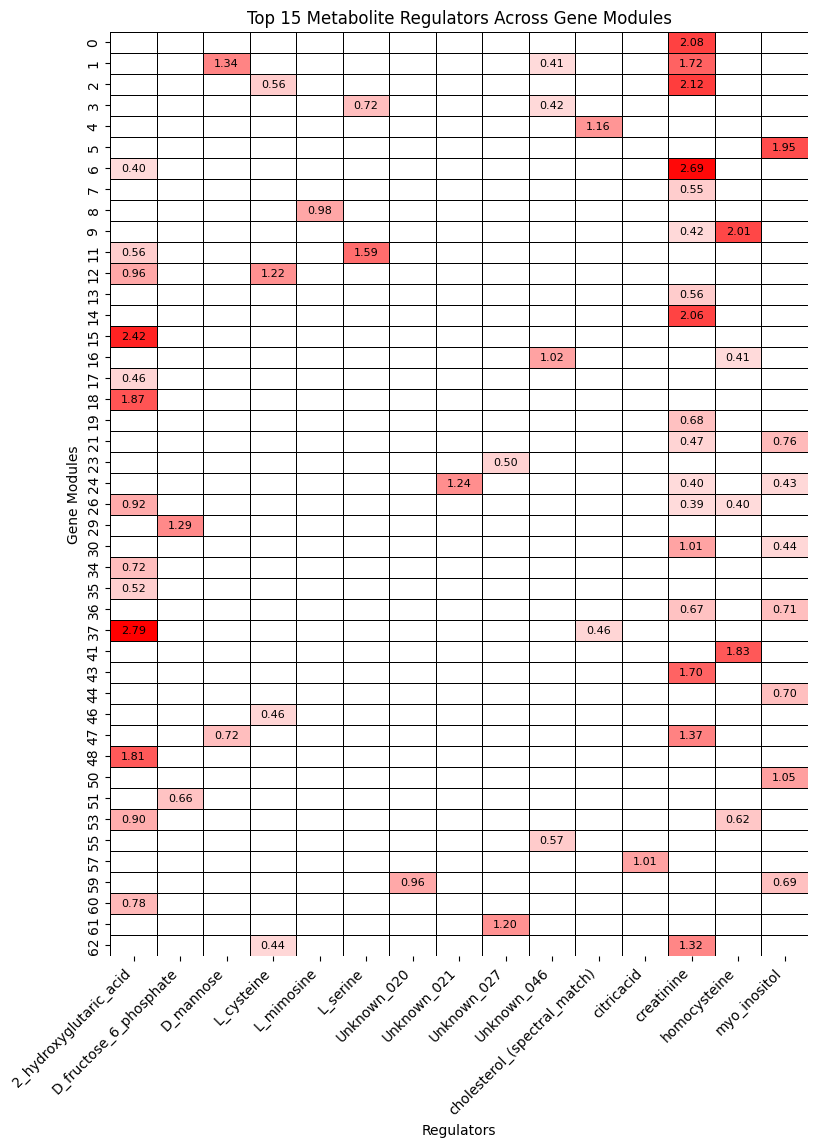

In [7]:
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

# Load regulator-module score data
regulator_file = f'./Lemon_out/Metabolite.percentile{percentile}.txt'
df = pd.read_csv(regulator_file, sep='\t')

# Select only relevant columns
df = df[['Regulator', 'Target', 'Score']]

# Get top 15 regulators based on highest scores
top_regulators = df.groupby('Regulator')['Score'].max().nlargest(15).index

# Filter data to keep only top regulators
df = df[df['Regulator'].isin(top_regulators)]

# Pivot to create a matrix where:
# - Rows = Gene modules (Targets)
# - Columns = Regulators
# - Values = Scores
heatmap_df = df.pivot(index='Target', columns='Regulator', values='Score')

# Fill NaN values with 0 (or min score if preferred)
heatmap_df = heatmap_df.fillna(0)

# Create a custom color map: grey for 0 and red for non-zero values
cmap = LinearSegmentedColormap.from_list('custom_cmap', ['white', 'red'])

# Set annotations: show value only if it's not zero
annot = heatmap_df.applymap(lambda x: '' if x == 0 else f'{x:.2f}')

# Plot heatmap with custom color map
plt.figure(figsize=(9, 12))
sns.heatmap(heatmap_df, cmap=cmap, annot=annot, fmt='', linewidths=0.5,linecolor='black' ,cbar=False, 
            annot_kws={'color': 'black', 'size': 8})


plt.title('Top 15 Metabolite Regulators Across Gene Modules')
plt.xlabel('Regulators')
plt.ylabel('Gene Modules')
plt.xticks(rotation=45, ha='right')

plt.savefig(f'./Networks/Metabolite.percentile{percentile}_top15_module_scores_all_modules.png', dpi=300, bbox_inches='tight')

plt.show()

In [8]:
########################################################################################################################################
# Create list files for visualization in moduleviewer
########################################################################################################################################

def createListFile(input_file, output_file):
    # Reading the input file into a Pandas DataFrame
    df = pd.read_csv(input_file, delimiter='\t', header=None)
    print(f"Processing {input_file}: {df.shape[1]} columns")
    
    # Check if df has 2 columns, then it is the cluster file
    if df.shape[1] == 2:
        df.columns = ['gene', 'cluster']
    elif df.shape[1] == 3: # Then it's a topreg file
        df.columns = ['regulator', 'target', 'score']
        df['cluster'] = df['target']
        df['gene'] = df['regulator']
        df = df[['gene', 'cluster']]
    elif df.shape[1] == 4: # Then it's a fold reg file
        df.columns = ['regulator', 'target', 'score', 'overall_rank']
        df['cluster'] = df['target']
        df['gene'] = df['regulator']
        df = df[['gene', 'cluster']]

    # Grouping by cluster and aggregating genes into a '|' separated string
    clusters_and_genes = df.groupby('cluster')['gene'].agg(lambda x: '|'.join(x)).to_dict()
    if 'Target' in clusters_and_genes:
        del clusters_and_genes['Target']
    
    # Formatting the output file
    out = [f"{cluster}\t{genes}\n" for cluster, genes in clusters_and_genes.items()]

    # Writing the output to a new file
    with open(output_file, 'w') as handle:
        handle.write(''.join(out))
    
    print(f"Written {len(clusters_and_genes)} clusters to {output_file}")

# Create list files with all modules (no filtering)
createListFile(clusterfile, './ModuleViewer_files/clusters_list.txt')
createListFile(topregfile_TF, './ModuleViewer_files/TF_regulators.topreg_list_test.txt')
createListFile(topregfile_metabolites, './ModuleViewer_files/Metabolite_regulators.topreg_list.txt')
createListFile('./Lemon_out/Lovering.percentile' + str(percentile) + '.txt', './ModuleViewer_files/Lovering.percentile' + str(percentile) + '_list.txt')
createListFile('./Lemon_out/Metabolite.percentile' + str(percentile) + '.txt', './ModuleViewer_files/Metabolite.percentile' + str(percentile) + '_list.txt')
createListFile(randomregfile_metabolites, './ModuleViewer_files/Metabolite.randomreg_list.txt')
createListFile(topregfile_lipids, './ModuleViewer_files/Lipid_regulators.topreg_list.txt')
createListFile('./Lemon_out/Lipid.percentile' + str(percentile) + '.txt', './ModuleViewer_files/Lipid.percentile' + str(percentile) + '_list.txt')
#createListFile(allregfile_lovering_proteins, './ModuleViewer_files/Lovering_proteins.allreg_list.txt')
#createListFile(randomregfile_lovering_proteins, './ModuleViewer_files/Lovering_proteins.randomreg_list.txt')
#createListFile(topregfile_lovering_proteins, './ModuleViewer_files/Lovering_proteins.topreg_list.txt')
#createListFile('./Lemon_out/Lovering_proteins.percentile' + str(percentile) + '.txt', './ModuleViewer_files/Lovering_proteins.percentile' + str(percentile) + '_list.txt')


Processing ./Lemon_out/tight_clusters.txt: 2 columns
Written 63 clusters to ./ModuleViewer_files/clusters_list.txt
Processing ./Lemon_out/Lovering.topreg.txt: 3 columns
Written 54 clusters to ./ModuleViewer_files/TF_regulators.topreg_list_test.txt
Processing ./Lemon_out/Metabolites.topreg.txt: 3 columns
Written 45 clusters to ./ModuleViewer_files/Metabolite_regulators.topreg_list.txt
Processing ./Lemon_out/Lovering.percentile2.txt: 4 columns
Written 60 clusters to ./ModuleViewer_files/Lovering.percentile2_list.txt
Processing ./Lemon_out/Metabolite.percentile2.txt: 4 columns
Written 55 clusters to ./ModuleViewer_files/Metabolite.percentile2_list.txt
Processing ./Lemon_out/Metabolites.randomreg.txt: 3 columns
Written 62 clusters to ./ModuleViewer_files/Metabolite.randomreg_list.txt
Processing ./Lemon_out/Lipids.topreg.txt: 3 columns
Written 57 clusters to ./ModuleViewer_files/Lipid_regulators.topreg_list.txt
Processing ./Lemon_out/Lipid.percentile2.txt: 4 columns
Written 60 clusters to .

In [9]:
clusters_list = pd.read_csv('./ModuleViewer_files/clusters_list.txt', sep='\t', header=None)
# Consider the first column as string
clusters_list[0] = clusters_list[0].astype(str)
cluster2gene = dict(zip(clusters_list[0], clusters_list[1]))
print(cluster2gene)
print(len(cluster2gene.keys()))

{'0': 'VSTM2L|GABRA5|SYT4|CREG2|SYNGR3|RBFOX1|KCNS1|SYP|GPR83|PRSS3|STX1B|TGFBR3L|GLT1D1|AK5|SPTB|C4orf50|VIPR1|TMEM130|IQSEC3|SYN1|CHD5|GREM2|SYT7|PRMT8|KCNJ4|HPCAL4|GABRD|ADAM11|EPHB6|KCTD16|GALNTL6|RASAL1|SLC17A7|CPLX1|DOC2A|GPR61|PACSIN1|GABRB2|PCP4L1|ARHGDIG|TMEM155|CABP1|CAMK2A|NRGN|DLGAP3|SNAP25|DDN|MTUS2|CACNA1B|GNG3|MPPED1|SLC6A17|SNCB|SLC6A7|SLC8A2|VWA5B2|PPP2R2C|SV2C|CALY|SLC30A3|SLC12A5|HPCA|NEFM|MAS1|CPNE6|C1QTNF4|UNC5A|AJAP1|SYT5|MFSD4|STYK1|GLS2|KIAA1644|ICAM5|ATP8A2|NEURL1|KIAA1045|ATP2B3|SYN2|CAMK1G|CRYM|MAP7D2|PHYHIP|FSTL4|TRHDE|RTN4RL1|PSD|RYR2', '1': 'GAD2|CACNG3|GJD2|NWD2|PCSK2|SYNPR|GABRG2|WSCD2|FADS6|GABRG3|KLHL1|CCK|GPR26|MYT1L|EPHA6|LRTM2|HCN1|SLC32A1|GRIN1|C1QL3|KCNV1|HTR5A|FRMPD4|SOHLH1|AMER3|TCERG1L|CDH18|KCNB2|CDH9|CHRM1|SSTR3|FAM153C|SVOP|KCNT1|KCNS2|CELF4|KCNJ3|CHRM2|GPR22|CPLX2|MAL2|HTR2A|FAM163B|CDH12|TMEM132D|VSNL1|SYT1|NEFL|PTPN5|UNC13C|SYT13|MCHR2|DLGAP2|CA7|GABRA4|OLFM3|EMX1|SV2B|RBFOX3|CCKBR|SLC35F3|CHGA|DNAJC5G|GABRA1|LYPD8|SULT4A1|KCNC2|CBLN2|FAM

In [10]:
########################################################################################################################################
# Calculate module coherence to filter modules before downstream analyses
########################################################################################################################################

# Remove modules with weak co-expression patterns
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

def calculate_module_coherence(expression_file, clusters_dict, coherence_threshold=0.6):
    """
    Calculate eigengenes, kME, and module coherence scores
    
    Parameters:
    - expression_file: path to expression data file
    - clusters_dict: dictionary mapping module -> list of genes
    - coherence_threshold: minimum coherence score to keep module
    
    Returns:
    - modules_to_remove: list of modules with low coherence
    - coherence_scores: dictionary of module -> coherence score
    """
    
    # Load expression data
    expression_data = pd.read_csv(expression_file, sep='\t')
    print(f"Loaded expression data: {expression_data.shape}")
    
    # Set gene symbols as index for easier subsetting
    expression_data_indexed = expression_data.set_index('symbol')
    
    # Remove non-numeric columns (keep only sample columns)
    numeric_cols = expression_data_indexed.select_dtypes(include=[np.number]).columns
    expression_matrix = expression_data_indexed[numeric_cols]
    
    coherence_scores = {}
    eigengenes = {}
    modules_to_remove = []
    
    print("Calculating module coherence scores...")
    
    for module, genes in clusters_dict.items():
        genes = genes.split('|')  # Ensure genes are split correctly
        try:
            # Get expression data for genes in this module
            module_genes_in_data = [gene for gene in genes if gene in expression_matrix.index]
            
            if len(module_genes_in_data) < 3:  # Need at least 3 genes for meaningful analysis
                print(f"Module {module}: Too few genes ({len(module_genes_in_data)}), marking for removal")
                modules_to_remove.append(str(module))
                coherence_scores[module] = 0.0
                continue
            
            # Extract expression data for module genes
            module_expression = expression_matrix.loc[module_genes_in_data]
            
            # Calculate eigengene using PCA (first principal component)
            pca = PCA(n_components=1)
            eigengene = pca.fit_transform(module_expression.T)
            eigengene_series = pd.Series(eigengene.flatten(), index=module_expression.columns)
            eigengenes[module] = eigengene_series
            
            # Calculate kME (correlation of each gene with eigengene)
            kme_values = []
            for gene in module_genes_in_data:
                gene_expression = module_expression.loc[gene]
                correlation, _ = pearsonr(gene_expression, eigengene_series)
                kme_values.append(abs(correlation))  # Use absolute correlation
            
            # Module coherence = mean absolute kME
            coherence_score = np.mean(kme_values)
            coherence_scores[module] = coherence_score
            
            # Check if module should be removed
            if coherence_score < coherence_threshold:
                modules_to_remove.append(str(module))
                print(f"Module {module}: Low coherence ({coherence_score:.3f} < {coherence_threshold}), marking for removal")

        except Exception as e:
            print(f"Error processing module {module}: {str(e)}")
            modules_to_remove.append(str(module))
            coherence_scores[module] = 0.0
    
    return modules_to_remove, coherence_scores, eigengenes

# Calculate module coherence using the cluster2gene dictionary
print("Analyzing module coherence...")
low_coherence_modules, coherence_scores, module_eigengenes = calculate_module_coherence(
    expression_location, 
    cluster2gene, 
    coherence_threshold=coherence_threshold
)

# Display results
print(f"\nCoherence Analysis Results:")
print(f"Total modules analyzed: {len(coherence_scores)}")
print(f"Modules with low coherence: {len(low_coherence_modules)}")
print(f"Low coherence modules: {low_coherence_modules}")

# Filter cluster2gene dictionary to remove low coherence modules
print(f"Original number of modules: {len(cluster2gene)}")
filtered_cluster2gene = {k: v for k, v in cluster2gene.items() if str(k) not in low_coherence_modules}
cluster2gene = filtered_cluster2gene
print(f"Modules after coherence filtering: {len(cluster2gene)}")

# How many modules do we keep?
n_modules = len(cluster2gene)
print(f"n_modules set to: {n_modules}")

# Create a DataFrame with coherence scores for analysis
coherence_df = pd.DataFrame(list(coherence_scores.items()), columns=['Module', 'Coherence_Score'])
coherence_df = coherence_df.sort_values('Coherence_Score', ascending=False)

# Save coherence scores to file for future reference
coherence_df.to_csv('./Networks/Module_coherence_scores.txt', sep='\t', index=False)
print("Coherence scores saved to Module_coherence_scores.txt")

Analyzing module coherence...
Loaded expression data: (5817, 76)
Calculating module coherence scores...
Module 16: Low coherence (0.448 < 0.5), marking for removal
Module 19: Low coherence (0.486 < 0.5), marking for removal
Module 22: Low coherence (0.268 < 0.5), marking for removal
Module 25: Low coherence (0.494 < 0.5), marking for removal
Module 27: Low coherence (0.422 < 0.5), marking for removal
Module 28: Low coherence (0.302 < 0.5), marking for removal
Module 31: Low coherence (0.345 < 0.5), marking for removal
Module 32: Low coherence (0.341 < 0.5), marking for removal
Module 34: Low coherence (0.498 < 0.5), marking for removal
Module 35: Low coherence (0.326 < 0.5), marking for removal
Module 38: Low coherence (0.404 < 0.5), marking for removal
Module 44: Low coherence (0.409 < 0.5), marking for removal
Module 49: Low coherence (0.382 < 0.5), marking for removal
Module 52: Low coherence (0.277 < 0.5), marking for removal
Module 55: Low coherence (0.398 < 0.5), marking for remo

In [11]:
########################################################################################################################################
# Order modules by coherence scores (higher coherence = better quality)
########################################################################################################################################

# Get list of filtered module names
filtered_module_names = list(cluster2gene.keys())

# Sort modules by coherence score (descending)
modules_ordered = {k: coherence_scores[k] for k in filtered_module_names}
modules_ordered = dict(sorted(modules_ordered.items(), key=lambda item: item[1], reverse=True))

# Save ordered modules to file
df = pd.DataFrame(list(modules_ordered.items()), columns=['Module', 'Coherence_Score'])
print(df)
df.to_csv('./Networks/Modules_ordered_by_coherence.txt', sep='\t', index=False)

print(f"\nModules ordered by coherence scores: {len(modules_ordered)}")
print(f"Using all {len(modules_ordered)} coherence-filtered modules for network construction")

   Module  Coherence_Score
0      39         0.904215
1       8         0.881698
2       0         0.840117
3      10         0.830620
4       1         0.823853
5       3         0.819649
6       5         0.807293
7      33         0.789875
8      24         0.780345
9      13         0.776867
10     46         0.772455
11     45         0.756731
12      9         0.747097
13      2         0.744573
14     37         0.739805
15     40         0.737339
16     62         0.730123
17     56         0.723125
18      4         0.722842
19      6         0.715216
20     21         0.712812
21     43         0.712032
22     53         0.702311
23     23         0.694701
24     41         0.692498
25     14         0.691851
26     26         0.675507
27      7         0.664069
28     61         0.645593
29     11         0.633512
30     36         0.627282
31     15         0.626649
32     51         0.614780
33     30         0.603388
34     50         0.602536
35     48         0.600555
3

In [12]:
# All modules that passed coherence filtering will be used
print(f"Using {len(cluster2gene)} modules that passed coherence filtering (threshold={coherence_threshold})")

Using 46 modules that passed coherence filtering (threshold=0.5)


In [13]:
# Prepare module list for network building
specific_modules = list(modules_ordered.keys())

# Convert to strings to ensure consistency
specific_modules = [str(module) for module in specific_modules]
print(f'{len(specific_modules)} modules will be used for network construction')

# Save module list to file
if not os.path.exists('./Networks'):
    os.makedirs('./Networks')
with open('./Networks/specific_modules.txt', 'w') as handle:
    for module in specific_modules:
        handle.write(module + '\n')
        
print(f"Module list saved to ./Networks/specific_modules.txt")

46 modules will be used for network construction
Module list saved to ./Networks/specific_modules.txt


In [14]:
########################################################################################################################################
# Build the network with selected regulators and modules
########################################################################################################################################

def build_network(reg_files, specific_modules_list=None):
    # Initialize an empty list to store DataFrames
    dfs = []

    global modules_name
    global modules_to_keep

    if specific_modules_list is not None:
        modules_to_keep = specific_modules_list
        modules_name = f'{len(modules_to_keep)}'
        print(f'Building network for {len(modules_to_keep)} modules')
    else:
        # Default: use all filtered modules
        modules_to_keep = list(cluster2gene.keys())
        modules_to_keep = [str(module) for module in modules_to_keep]
        modules_name = f'{len(modules_to_keep)}'
        print(f'Building network for {len(modules_to_keep)} modules')

    print(f'Modules included: {modules_to_keep[:10]}...')  # Show first 10

    for reg_file in reg_files: # Loop over regulator files
        data = pd.read_csv(reg_file, sep='\t')
        if len(data.columns) == 3:
            data.columns = ['Regulator', 'Target', 'Score']
        elif len(data.columns) == 4:
            data.columns = ['Regulator', 'Target', 'Score', 'Overall_rank']

        data['Target'] = data['Target'].astype(str)
        
        # Loop over this dataframe
        for index, row in data.iterrows():
            # Get Regulator
            regulator = row['Regulator']
            # Get module
            module = row['Target']
            
            if str(module) in modules_to_keep:
                genes = cluster2gene.get(module, [])
                if isinstance(genes, str):
                    genes = genes.split('|')  # Ensure genes are split correctly
                
                for gene in genes:
                    if 'Lovering_proteins' in reg_file:
                        # Create a DataFrame for each gene - Protein-gene interactions
                        gene_df = pd.DataFrame({'Regulator': [regulator], 'Target': [gene], 'Score': [row['Score']], 'Lemon_module': str(module), 'Type': ['Protein-gene']})
                    elif 'Lovering' in reg_file:
                        # Create a DataFrame for each gene - TF-gene interactions
                        gene_df = pd.DataFrame({'Regulator': [regulator], 'Target': [gene], 'Score': [row['Score']], 'Lemon_module': str(module), 'Type': ['TF-gene']})
                    elif 'Metabolite' in reg_file:
                        gene_df = pd.DataFrame({'Regulator': [regulator], 'Target': [gene], 'Score': [row['Score']], 'Lemon_module': str(module), 'Type': ['Metabolite-gene']})
                    elif 'Lipid' in reg_file:
                        gene_df = pd.DataFrame({'Regulator': [regulator], 'Target': [gene], 'Score': [row['Score']], 'Lemon_module': str(module), 'Type': ['Lipid-gene']})
                    
                    dfs.append(gene_df)  # Append the DataFrame to the list
    
    # Concatenate all DataFrames in the list
    if dfs:
        network_df = pd.concat(dfs, ignore_index=True)
    else:
        print("Warning: No network edges found!")
        network_df = pd.DataFrame(columns=['Regulator', 'Target', 'Score', 'Lemon_module', 'Type'])

    # Create folder Networks if it does not exist
    if not os.path.exists('./Networks'):
        os.makedirs('./Networks')

    # Write to file
    network_df.to_csv(f'./Networks/LemonNetwork_percentile{percentile}_{modules_name}modules.txt', sep='\t', index=False)
    print(f"Network saved to: ./Networks/LemonNetwork_percentile{percentile}_{modules_name}modules.txt")
    
    return network_df

# Build network with filtered modules
reg_files = [f'./Lemon_out/Lovering.percentile{percentile}.txt', f'./Lemon_out/Metabolite.percentile{percentile}.txt', f'./Lemon_out/Lipid.percentile{percentile}.txt']
network_df = build_network(reg_files, specific_modules_list=specific_modules)

Building network for 46 modules
Modules included: ['39', '8', '0', '10', '1', '3', '5', '33', '24', '13']...
Network saved to: ./Networks/LemonNetwork_percentile2_46modules.txt


In [15]:
network_df

,Regulator,Target,Score,Lemon_module,Type
0,EMX1,VSTM2L,1.279007,0,TF-gene
1,EMX1,GABRA5,1.279007,0,TF-gene
2,EMX1,SYT4,1.279007,0,TF-gene
3,EMX1,CREG2,1.279007,0,TF-gene
4,EMX1,SYNGR3,1.279007,0,TF-gene
...,...,...,...,...,...
25829,PE(P_16_0/22_4),NXPH3,0.112977,62,Lipid-gene
25830,PE(P_16_0/22_4),COL9A1,0.112977,62,Lipid-gene
25831,PE(P_16_0/22_4),GAD1,0.112977,62,Lipid-gene
25832,PE(P_16_0/22_4),FRMPD1,0.112977,62,Lipid-gene


In [16]:
# How many unique genes in Target column?
print(f'The network contains {network_df["Target"].nunique()} unique genes.')
for reg_type in network_df['Type'].unique():

    print(f'The network contains {network_df[network_df["Type"] == reg_type]["Regulator"].nunique()} unique {reg_type.split("-")[0]} regulators.')

    # And how many unique Regulator-Lemon_module combinations?
    reg_module_combos = network_df[network_df["Type"] == reg_type][["Regulator", "Lemon_module"]].drop_duplicates()
    print(f'The network contains {len(reg_module_combos)} unique {reg_type.split("-")[0]}-module combinations.')

The network contains 1930 unique genes.
The network contains 100 unique TF regulators.
The network contains 198 unique TF-module combinations.
The network contains 48 unique Metabolite regulators.
The network contains 107 unique Metabolite-module combinations.
The network contains 155 unique Lipid regulators.
The network contains 291 unique Lipid-module combinations.


In [17]:
# How many unique metabolite-gene interactions?
metabolite_interactions = network_df[network_df['Type'] == 'Metabolite-gene']
print(f'The network contains {len(metabolite_interactions)} unique metabolite-gene interactions.')
# How many unique TF-gene interactions?
tf_interactions = network_df[network_df['Type'] == 'TF-gene']
print(f'The network contains {len(tf_interactions)} unique TF-gene interactions.')
# How many unique lipid-gene interactions?
lipid_interactions = network_df[network_df['Type'] == 'Lipid-gene']
print(f'The network contains {len(lipid_interactions)} unique lipid-gene interactions.')

The network contains 5018 unique metabolite-gene interactions.
The network contains 8250 unique TF-gene interactions.
The network contains 12566 unique lipid-gene interactions.


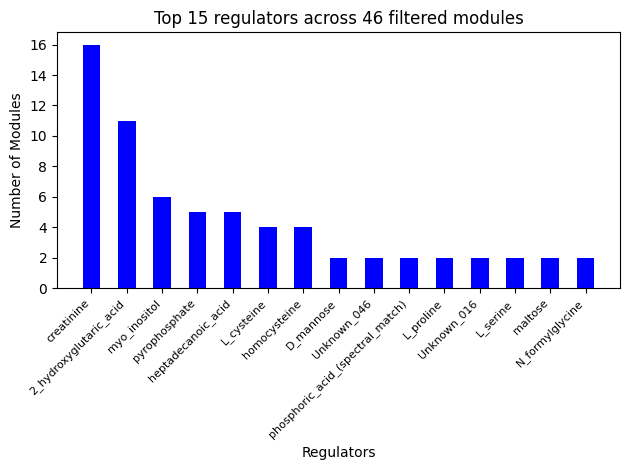

Saved plot for 48 unique regulators


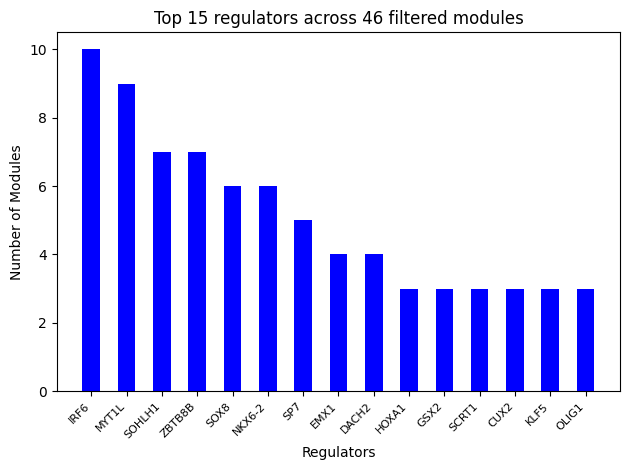

Saved plot for 100 unique regulators


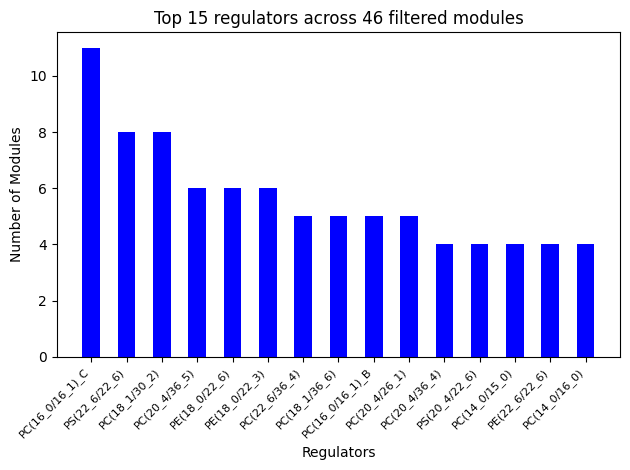

Saved plot for 155 unique regulators


In [18]:
# Create similar plot but only for the top 30 connected regulators (filtered modules only)
def create_reg_distribution_top_filtered(reg_file_list, modules_to_keep):

    with open('./ModuleViewer_files/' + reg_file_list, 'r') as handle:
        regs = {}
        for line in handle:
            line = line.rstrip().split('\t')
            if len(line) < 2:
                continue
            module = line[0]
            if str(module) not in [str(m) for m in modules_to_keep]:
                continue
            regulators = line[1].split('|')
            for regulator in regulators:
                if regulator in regs:
                    regs[regulator] += 1
                else:
                    regs[regulator] = 1

    if not regs:
        print(f"Warning: No regulators found for file {reg_file_list}")
        return
    
    # Sort keys based on counts in decreasing order
    sorted_keys = sorted(regs, key=regs.get, reverse=True)

    # Extract sorted keys and counts
    sorted_counts = [regs[key] for key in sorted_keys]

    # Plotting
    fig, ax = plt.subplots()
    bars = ax.bar(sorted_keys[:15], sorted_counts[:15], width=0.5, color='blue')

    ax.set_xlabel('Regulators')
    ax.set_ylabel('Number of Modules')
    ax.set_title(f'Top 15 regulators across {len(modules_to_keep)} filtered modules')

    ax.set_xticks(range(len(sorted_keys[:15])))
    ax.set_xticklabels(sorted_keys[:15], rotation=45, ha='right', fontsize=8)  # Adjust fontsize for better readability
    plt.tight_layout()  # Ensure labels are not cut off

    # Explicitly set the face color
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Save the plot with a white background
    plt.savefig('./Networks/'+reg_file_list[:-3] + f'_distribution_plot_top15_filtered_{len(modules_to_keep)}modules.png', 
                facecolor=fig.get_facecolor(), edgecolor='none', dpi=600)

    plt.show()
    print(f"Saved plot for {len(sorted_keys)} unique regulators")

# Create plots for filtered modules
if 'modules_to_keep' in globals():
    create_reg_distribution_top_filtered(f'Metabolite.percentile{percentile}_list.txt', modules_to_keep)
    create_reg_distribution_top_filtered(f'Lovering.percentile{percentile}_list.txt', modules_to_keep)
    create_reg_distribution_top_filtered(f'Lipid.percentile{percentile}_list.txt', modules_to_keep)
else:
    print("Warning: modules_to_keep not defined, using all available modules")
    create_reg_distribution_top_filtered(f'Metabolite.percentile{percentile}_list.txt', list(cluster2gene.keys()))
    create_reg_distribution_top_filtered(f'Lovering.percentile{percentile}_list.txt', list(cluster2gene.keys()))
    create_reg_distribution_top_filtered(f'Lipid.percentile{percentile}_list.txt', list(cluster2gene.keys()))


In [19]:
########################################################################################################################################
# Create dictionary that maps regulators to targets for selected modules
########################################################################################################################################

metabolites_network = network_df[network_df['Type'] == 'Metabolite-gene']
TFs_network = network_df[network_df['Type'] == 'TF-gene']
lipids_network = network_df[network_df['Type'] == 'Lipid-gene']
proteins_network = network_df[network_df['Type'] == 'Protein-gene']

metabolites2targets = {}
for index, row in metabolites_network.iterrows():
    metabolite = row['Regulator']
    target = row['Target']
    if metabolite in metabolites2targets:
        metabolites2targets[metabolite].append(target)
    else:
        metabolites2targets[metabolite] = [target]

TFs2targets = {}
for index, row in TFs_network.iterrows():
    TF = row['Regulator']
    target = row['Target']
    if TF in TFs2targets:
        TFs2targets[TF].append(target)
    else:
        TFs2targets[TF] = [target]

regulator2module = {}
for index, row in network_df.iterrows():
    regulator = row['Regulator']
    module = row['Lemon_module']
    if regulator in regulator2module:
        if module not in regulator2module[regulator]:
            regulator2module[regulator].append(module)
    else:
        regulator2module[regulator] = [module]

lipids2targets = {}
for index, row in lipids_network.iterrows():
    lipid = row['Regulator']
    target = row['Target']
    if lipid in lipids2targets:
        lipids2targets[lipid].append(target)
    else:
        lipids2targets[lipid] = [target]

In [20]:
TFs_network

,Regulator,Target,Score,Lemon_module,Type
0,EMX1,VSTM2L,1.279007,0,TF-gene
1,EMX1,GABRA5,1.279007,0,TF-gene
2,EMX1,SYT4,1.279007,0,TF-gene
3,EMX1,CREG2,1.279007,0,TF-gene
4,EMX1,SYNGR3,1.279007,0,TF-gene
...,...,...,...,...,...
8245,HAND2,NXPH3,0.126336,62,TF-gene
8246,HAND2,COL9A1,0.126336,62,TF-gene
8247,HAND2,GAD1,0.126336,62,TF-gene
8248,HAND2,FRMPD1,0.126336,62,TF-gene


In [21]:
# Create df with metabolites and their targets
metabolites2targets_df = pd.DataFrame(list(metabolites2targets.items()), columns=['Regulator', 'Targets'])
TFs2targets_df = pd.DataFrame(list(TFs2targets.items()), columns=['Regulator', 'Targets'])
lipids2targets_df = pd.DataFrame(list(lipids2targets.items()), columns=['Regulator', 'Targets'])


# Convert list of targets to | separated string
metabolites2targets_df['Targets'] = metabolites2targets_df['Targets'].apply(lambda x: '|'.join(x))
TFs2targets_df['Targets'] = TFs2targets_df['Targets'].apply(lambda x: '|'.join(x))
lipids2targets_df['Targets'] = lipids2targets_df['Targets'].apply(lambda x: '|'.join(x))


# Use actual number of modules for filename
actual_n_modules = len(specific_modules)

# Write to file
metabolites2targets_df.to_csv(f'./Networks/Metabolites2targets_percentile{percentile}_{actual_n_modules}_modules.txt', sep='\t', index=False)
TFs2targets_df.to_csv(f'./Networks/TFs2targets_percentile{percentile}_{actual_n_modules}_modules.txt', sep='\t', index=False)
lipids2targets_df.to_csv(f'./Networks/Lipids2targets_percentile{percentile}_{actual_n_modules}_modules.txt', sep='\t', index=False)


print(f"Saved target files for {actual_n_modules} filtered modules")
print(f"Metabolites: {len(metabolites2targets_df)} regulators")
print(f"TFs: {len(TFs2targets_df)} regulators")
print(f"Lipids: {len(lipids2targets_df)} regulators")


Saved target files for 46 filtered modules
Metabolites: 48 regulators
TFs: 100 regulators
Lipids: 155 regulators


In [22]:
########################################################################################################################################
# Create ranked regulator file that summarizes regulator scores across modules that are retained in the network after selection 
########################################################################################################################################

def create_ranked_reg_file(network, n_modules_actual):
    # network = pd.read_csv(networkfile, sep='\t')
    type = network['Type'].unique()[0].split('-')[0]
    # remove Target and Type columns
    network = network.drop(['Target', 'Type'], axis=1)
    
    # Group by Regulator and calculate the mean score (actually mean = score since all regulator-module scores are the same within a single module)
    # Group by 'Regulator' and retain only 'Lemon_module' and 'Score' columns
    grouped_df = network.groupby(['Regulator', 'Lemon_module'])[['Score']].first().reset_index()
    
    # Group by 'Regulator' and sum the 'Score' column
    sum_scores_df = grouped_df.groupby('Regulator')[['Score']].sum().reset_index()

    # Sort the dataframe based on the sum of scores
    sum_scores_df = sum_scores_df.sort_values(by='Score', ascending=False)

    # Add columns with number of target modules, number of target genes, target modules and target genes
    for row in sum_scores_df.iterrows():
        regulator = row[1]['Regulator']
        modules = regulator2module[regulator]
        sum_scores_df.at[row[0], 'N_modules'] = int(len(modules))
        
        # Check which dictionary contains this regulator
        if regulator in metabolites2targets:
            sum_scores_df.at[row[0], 'N_targets'] = int(len(metabolites2targets[regulator]))
            sum_scores_df.at[row[0], 'Targets'] = '|'.join(metabolites2targets[regulator])
        elif regulator in TFs2targets:
            sum_scores_df.at[row[0], 'N_targets'] = int(len(TFs2targets[regulator]))
            sum_scores_df.at[row[0], 'Targets'] = '|'.join(TFs2targets[regulator])
        elif regulator in lipids2targets:
            sum_scores_df.at[row[0], 'N_targets'] = int(len(lipids2targets[regulator]))
            sum_scores_df.at[row[0], 'Targets'] = '|'.join(lipids2targets[regulator])

       
        sum_scores_df.at[row[0], 'Modules'] = '|'.join(modules)
    
    print(f"Top {type} regulators:")
    print(sum_scores_df.head())
    
    # Write to file
    sum_scores_df.to_csv(f'./Networks/Network_percentile{percentile}_{n_modules_actual}_modules_{type}_ranked_regulators.txt', sep='\t', index=False)
    print(f"Saved to: ./Networks/Network_percentile{percentile}_{n_modules_actual}_modules_{type}_ranked_regulators.txt")

# Use the actual number of modules in the network
actual_n_modules = len(specific_modules)
create_ranked_reg_file(metabolites_network, actual_n_modules)
create_ranked_reg_file(TFs_network, actual_n_modules)
create_ranked_reg_file(lipids_network, actual_n_modules)

Top Metabolite regulators:
                 Regulator      Score  N_modules  N_targets  \
35              creatinine  19.538497       16.0      971.0   
0   2_hydroxyglutaric_acid  13.855883       11.0      600.0   
44            myo_inositol   5.331377        6.0      219.0   
41            homocysteine   4.849887        4.0      164.0   
47           pyrophosphate   3.121501        5.0      169.0   

                                              Targets  \
35  VSTM2L|GABRA5|SYT4|CREG2|SYNGR3|RBFOX1|KCNS1|S...   
0   JPH3|RUNDC3A|JAKMIP1|CCDC64|RBP4|ZCCHC12|CCDC1...   
44  ANPEP|STC1|SAA2|OSM|HP|CXCL1|PTGS2|CD300E|CXCL...   
41  ZDHHC22|SLIT1|GRIA2|DGKB|NRXN2|COL20A1|ELAVL3|...   
47  GAD2|CACNG3|GJD2|NWD2|PCSK2|SYNPR|GABRG2|WSCD2...   

                                      Modules  
35  0|1|2|6|7|9|13|14|21|24|26|30|36|43|47|62  
0             6|11|12|15|17|18|26|37|48|53|60  
44                           5|21|24|30|36|50  
41                                 9|26|41|53  
47         

In [23]:
########################################################################################################################################
# Create regulator overview tables: number of modules, summed score, highest score - ordered by descending n_modules
########################################################################################################################################

def create_regulator_overview_table(network, n_modules_actual):
    """
    Create an overview table for regulators with:
    - Number of modules they regulate
    - Summed score across all modules
    - Highest regulator-module score
    Ordered by descending number of modules.
    """
    type_name = network['Type'].unique()[0].split('-')[0]
    
    # Remove Target and Type columns for processing
    network_proc = network.drop(['Target', 'Type'], axis=1)
    
    # Group by Regulator and Lemon_module to get unique regulator-module pairs with their scores
    grouped_df = network_proc.groupby(['Regulator', 'Lemon_module'])[['Score']].first().reset_index()
    
    # For each regulator, calculate:
    # 1. Number of modules
    # 2. Sum of scores across modules
    # 3. Highest score across modules
    regulator_stats = grouped_df.groupby('Regulator').agg({
        'Lemon_module': 'count',  # Number of modules
        'Score': ['sum', 'max']   # Sum and max of scores
    }).reset_index()
    
    # Flatten column names
    regulator_stats.columns = ['Regulator', 'N_modules', 'Summed_score', 'Highest_score']
    
    # Sort by number of modules (descending)
    regulator_stats = regulator_stats.sort_values(by='N_modules', ascending=False)
    
    # Round scores to 4 decimal places for readability
    regulator_stats['Summed_score'] = regulator_stats['Summed_score'].round(4)
    regulator_stats['Highest_score'] = regulator_stats['Highest_score'].round(4)
    
    print(f"\n{'='*80}")
    print(f"{type_name} Regulator Overview (ordered by number of modules)")
    print(f"{'='*80}")
    print(regulator_stats.head(15))
    print(f"\nTotal {type_name} regulators: {len(regulator_stats)}")
    
    # Write to file
    output_file = f'./Networks/Network_percentile{percentile}_{n_modules_actual}_modules_{type_name}_overview_by_n_modules.txt'
    regulator_stats.to_csv(output_file, sep='\t', index=False)
    print(f"Saved to: {output_file}")
    
    return regulator_stats

# Create overview tables for each regulator type
print("\n" + "="*80)
print("CREATING REGULATOR OVERVIEW TABLES")
print("="*80)

actual_n_modules = len(specific_modules)

# Create overview for each regulator type
metabolites_overview = create_regulator_overview_table(metabolites_network, actual_n_modules)
TFs_overview = create_regulator_overview_table(TFs_network, actual_n_modules)
lipids_overview = create_regulator_overview_table(lipids_network, actual_n_modules)


CREATING REGULATOR OVERVIEW TABLES

Metabolite Regulator Overview (ordered by number of modules)
                 Regulator  N_modules  Summed_score  Highest_score
35              creatinine         16       19.5385         2.6949
0   2_hydroxyglutaric_acid         11       13.8559         2.7885
44            myo_inositol          6        5.3314         1.9506
47           pyrophosphate          5        3.1215         0.9296
40      heptadecanoic_acid          5        2.7277         0.6934
9               L_cysteine          4        2.6764         1.2170
41            homocysteine          4        4.8499         2.0063
8                D_mannose          2        2.0582         1.3418
21             Unknown_016          2        0.8056         0.4128
26             Unknown_027          2        1.6989         1.1979
18             Unknown_006          2        0.8334         0.4443
3   D_fructose_6_phosphate          2        1.9500         1.2947
13               L_proline     

In [23]:
def createCytoscapeFiles(modules_to_use=None, input_file_metabolites=False, input_file_TFs=False):
    if modules_to_use is None:
        # Use all filtered modules if none specified
        modules_to_use = list(cluster2gene.keys())
    
    # Ensure modules are integers for consistency
    modules = [int(i) if str(i).isdigit() else str(i) for i in modules_to_use]
    print(f"Creating Cytoscape files for {len(modules)} modules: {modules[:10]}...")
    
    n_modules = len(modules)
    
    with open(f'./Networks/Cytoscape_network_{n_modules}_modules_percentile{percentile}_filtered.txt', 'w') as handle:
        data_frames = []
        
        if input_file_TFs:
            # Read file as pd dataframe
            data = pd.read_csv(input_file_TFs, sep='\t')
            # Select rows in which the value of column 'Target' is present in the list of modules
            data = data.loc[data['Target'].isin(modules)]
            print(f"TF regulators: {len(data)} interactions for filtered modules")
            data_frames.append(data)
            
        if input_file_metabolites:
            data2 = pd.read_csv(input_file_metabolites, sep='\t')
            data2 = data2.loc[data2['Target'].isin(modules)]
            print(f"Metabolite regulators: {len(data2)} interactions for filtered modules")
            data_frames.append(data2)
        
        if data_frames:
            # concatenate the dataframes
            combined_data = pd.concat(data_frames, ignore_index=True)
            # Write the dataframe to a file
            combined_data.to_csv(handle, sep='\t', index=False)
            
            # Now we need to create an attributes file
            regulators = combined_data['Regulator'].unique().tolist()
            targets = combined_data['Target'].unique().tolist()
            
            with open(f'./Networks/Cytoscape_attributes_{n_modules}_modules_percentile{percentile}_filtered.txt', 'w') as handle2:
                handle2.write('Name' + '\t' + 'Type' + '\n')
                for regulator in regulators:
                    if regulator in TFs2targets.keys():
                        handle2.write(regulator + '\t' + 'TF' + '\n')
                    elif regulator in metabolites2targets.keys():
                        handle2.write(regulator + '\t' + 'Metabolite' + '\n')
                    elif regulator in lipids2targets.keys():
                        handle2.write(regulator + '\t' + 'Lipid' + '\n')
                for target in targets:
                    handle2.write(str(target) + '\t' + 'Module' + '\n')
            
            print(f"Created Cytoscape files for {len(regulators)} regulators and {len(targets)} modules")
        else:
            print("Warning: No data to write to Cytoscape files")

# Create Cytoscape files for filtered modules
createCytoscapeFiles(
    modules_to_use=specific_modules, 
    input_file_TFs=f'./Lemon_out/Lovering.percentile{percentile}.txt', 
    input_file_metabolites=f'./Lemon_out/Metabolite.percentile{percentile}.txt',
   
)

Creating Cytoscape files for 46 modules: [39, 8, 0, 10, 1, 3, 5, 33, 24, 13]...
TF regulators: 198 interactions for filtered modules
Metabolite regulators: 107 interactions for filtered modules
Created Cytoscape files for 148 regulators and 46 modules
